# 01 — Exploratory Data Analysis\n\n**Dataset:** David Cariboo *Player Scores* (Transfermarkt) via Kaggle — `davidcariboo/player-scores`, version 671 (fetched 2026-07-08).\n\n**Goal:** understand the raw tables before building the M2 player-season feature table. Specifically:\n- shapes, dtypes, and missingness in each table\n- distributions of the fields the aging-curve analysis depends on (age, minutes, position, market value)\n- how much data survives once we restrict to the big-five leagues, 2020-2023 seasons, and the `MIN_MINUTES` filter\n- data-quality sanity checks (duplicates, implausible values, unmapped positions)\n\nThis notebook is read-only exploration — no processed output is written here. Findings inform the decisions we make in `02_features.ipynb` (M2)."

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)

TODAY = pd.Timestamp("2026-07-08")  # fixed "as of" date so re-runs are deterministic
print("Data root:", config.DATA_RAW)

Data root: C:\Users\thoma\soccer-aging-curves\data\raw


## 1. Load all tables and get oriented

Load every core table and look at shape, dtypes, and a sample of rows before doing anything else.

In [2]:
tables = {}
for key, filename in config.TABLES.items():
    df = pd.read_csv(config.DATA_RAW / filename, low_memory=False)
    tables[key] = df
    print(f"{key:12s} {filename:24s} shape={df.shape}")

players, appearances, valuations, games, competitions = (
    tables["players"], tables["appearances"], tables["valuations"],
    tables["games"], tables["competitions"],
)

players      players.csv              shape=(48380, 26)


appearances  appearances.csv          shape=(1889406, 13)


valuations   player_valuations.csv    shape=(656301, 6)


games        games.csv                shape=(88943, 23)
competitions competitions.csv         shape=(65, 11)


In [3]:
def missingness(df: pd.DataFrame) -> pd.DataFrame:
    """dtype + % missing per column, sorted worst-first."""
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(1),
    })
    return out.sort_values("pct_missing", ascending=False)

for key, df in tables.items():
    print(f"\n=== {key} ===")
    display(missingness(df))


=== players ===


,dtype,n_missing,pct_missing
current_national_team_id,float64,42766,88.4
international_caps,float64,30025,62.1
international_goals,float64,30025,62.1
agent_name,object,22517,46.5
contract_expiration_date,object,16632,34.4
highest_market_value_in_eur,float64,6874,14.2
market_value_in_eur,float64,6874,14.2
country_of_birth,object,5315,11.0
foot,object,5288,10.9
city_of_birth,object,5037,10.4



=== appearances ===


,dtype,n_missing,pct_missing
appearance_id,object,0,0.0
game_id,int64,0,0.0
player_id,int64,0,0.0
player_club_id,int64,0,0.0
player_current_club_id,int64,0,0.0
date,object,0,0.0
player_name,object,2,0.0
competition_id,object,0,0.0
yellow_cards,int64,0,0.0
red_cards,int64,0,0.0



=== valuations ===


,dtype,n_missing,pct_missing
player_club_domestic_competition_id,object,93012,14.2
player_id,int64,0,0.0
date,object,0,0.0
market_value_in_eur,int64,0,0.0
current_club_name,object,0,0.0
current_club_id,float64,1,0.0



=== games ===


,dtype,n_missing,pct_missing
away_club_position,float64,25377,28.5
home_club_position,float64,25377,28.5
attendance,float64,10808,12.2
home_club_formation,object,8777,9.9
away_club_formation,object,8651,9.7
competition_type,object,1214,1.4
away_club_manager_name,object,844,0.9
home_club_manager_name,object,844,0.9
referee,object,678,0.8
stadium,object,242,0.3



=== competitions ===


,dtype,n_missing,pct_missing
total_clubs,float64,15,23.1
country_name,object,12,18.5
domestic_league_code,object,12,18.5
name,object,0,0.0
competition_code,object,0,0.0
competition_id,object,0,0.0
sub_type,object,0,0.0
country_id,int64,0,0.0
type,object,0,0.0
confederation,object,0,0.0


## 2. `players` — positions, physical attributes, market value

This table is the source of `date_of_birth` (age) and `position` (for `POSITION_GROUPS`) —
two fields the entire aging-curve analysis depends on, so their quality matters a lot.

In [4]:
print("Raw `position` value counts:")
print(players["position"].value_counts(dropna=False))

print("\nMapped via config.POSITION_GROUPS — anything NOT mapped becomes NaN:")
mapped = players["position"].map(config.POSITION_GROUPS)
print(mapped.value_counts(dropna=False))

unmapped = players.loc[mapped.isna() & players["position"].notna(), "position"].unique()
print("\nUnmapped raw position values (need attention in M2):", unmapped)

Raw `position` value counts:
position
Defender      15414
Midfield      13786
Attack        13064
Goalkeeper     5611
Missing         505
Name: count, dtype: int64

Mapped via config.POSITION_GROUPS — anything NOT mapped becomes NaN:
position
Defender      15414
Midfielder    13786
Forward       13064
Goalkeeper     5611
NaN             505
Name: count, dtype: int64

Unmapped raw position values (need attention in M2): ['Missing']


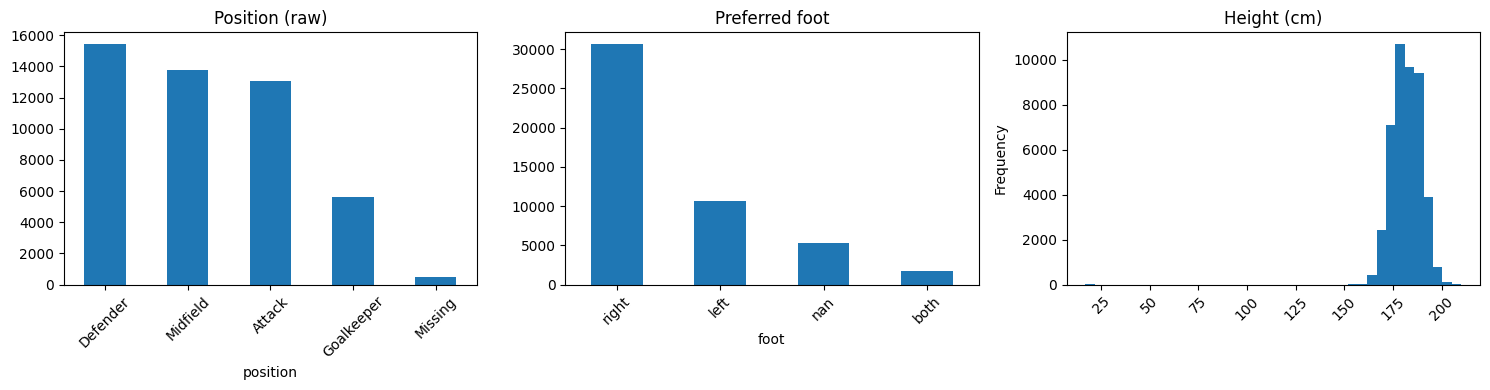

date_of_birth range: 1968-07-31 00:00:00 to 2011-02-23 00:00:00
date_of_birth missing: 49 / 48380

market_value_in_eur summary (current, EUR):
count    4.150600e+04
mean     1.511445e+06
std      5.855964e+06
min      1.000000e+04
25%      1.000000e+05
50%      2.750000e+05
75%      7.000000e+05
max      2.000000e+08
Name: market_value_in_eur, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

players["position"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], title="Position (raw)")
players["foot"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], title="Preferred foot")
players["height_in_cm"].dropna().plot(kind="hist", bins=40, ax=axes[2], title="Height (cm)")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

dob_parsed = pd.to_datetime(players["date_of_birth"], errors="coerce")
print("date_of_birth range:", dob_parsed.min(), "to", dob_parsed.max())
print("date_of_birth missing:", dob_parsed.isna().sum(), "/", len(players))
print("\nmarket_value_in_eur summary (current, EUR):")
print(players["market_value_in_eur"].describe())

In [6]:
# Sanity checks: duplicate player_ids, implausible birth dates
print("Duplicate player_id rows:", players["player_id"].duplicated().sum())

dob = pd.to_datetime(players["date_of_birth"], errors="coerce")
age_now = (TODAY - dob).dt.days / 365.25
implausible = players.loc[(age_now < 14) | (age_now > 50)]
print(f"Players with implausible current age (<14 or >50): {len(implausible)}")
if len(implausible):
    display(implausible[["player_id", "name", "date_of_birth"]].head(10))

Duplicate player_id rows: 0
Players with implausible current age (<14 or >50): 98


,player_id,name,date_of_birth
8,162,Marc Ziegler,1976-06-13 00:00:00
19,447,Oka Nikolov,1974-05-25 00:00:00
22,557,Simon Jentzsch,1976-05-04 00:00:00
51,1161,Javier Zanetti,1973-08-10 00:00:00
145,3131,Kevin Phillips,1973-07-25 00:00:00
147,3139,David Beckham,1975-05-02 00:00:00
148,3146,Shay Given,1976-04-20 00:00:00
149,3151,Carlo Cudicini,1973-09-06 00:00:00
179,3287,Steve Banks,1972-02-09 00:00:00
192,3357,Mark Schwarzer,1972-10-06 00:00:00


## 3. `appearances` — the performance backbone

One row per (player, game). This is what gets aggregated into player-seasons in M2.

In [7]:
app_dates = pd.to_datetime(appearances["date"], errors="coerce")
print("appearances date range:", app_dates.min(), "to", app_dates.max())
print("Unique players:", appearances["player_id"].nunique())
print("Unique games:", appearances["game_id"].nunique())
print("Duplicate appearance_id:", appearances["appearance_id"].duplicated().sum())

# A player should appear at most once per game
dup_player_game = appearances.duplicated(subset=["player_id", "game_id"]).sum()
print("Duplicate (player_id, game_id) pairs:", dup_player_game)

appearances date range: 2012-07-03 00:00:00 to 2026-06-28 00:00:00
Unique players: 28942
Unique games: 73388


Duplicate appearance_id: 0


Duplicate (player_id, game_id) pairs: 0


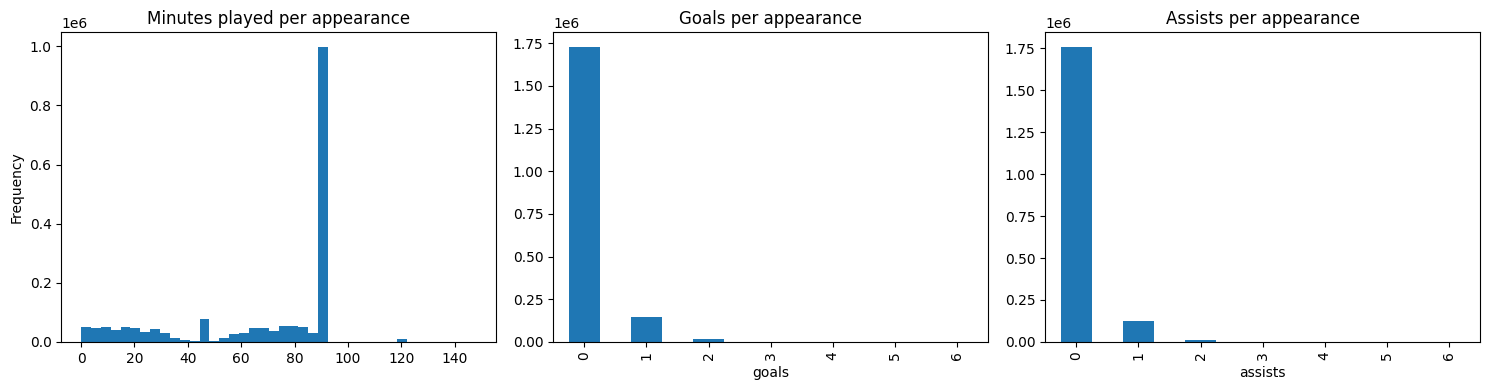

minutes_played summary:
count    1.889406e+06
mean     6.857318e+01
std      3.017011e+01
min      0.000000e+00
25%      4.500000e+01
50%      9.000000e+01
75%      9.000000e+01
max      1.480000e+02
Name: minutes_played, dtype: float64

yellow_cards / red_cards totals: 274060 / 6588


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

appearances["minutes_played"].dropna().plot(kind="hist", bins=40, ax=axes[0], title="Minutes played per appearance")
appearances["goals"].value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Goals per appearance")
appearances["assists"].value_counts().sort_index().plot(kind="bar", ax=axes[2], title="Assists per appearance")

plt.tight_layout()
plt.show()

print("minutes_played summary:")
print(appearances["minutes_played"].describe())
print("\nyellow_cards / red_cards totals:", appearances["yellow_cards"].sum(), "/", appearances["red_cards"].sum())

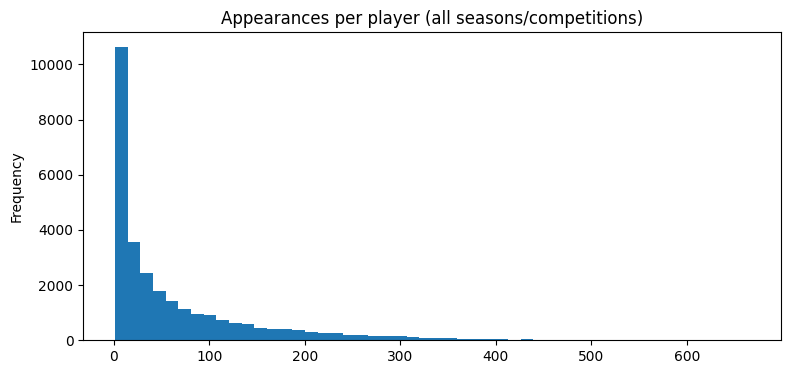

count    28942.000000
mean        65.282496
std         87.169318
min          1.000000
25%          6.000000
50%         29.000000
75%         90.000000
max        665.000000
dtype: float64

competition_id coverage (top 15 by appearance count):
competition_id
IT1     154999
ES1     153675
GB1     149685
FR1     143246
TR1     132007
L1      124511
NL1     119807
PO1     119627
BE1     100778
RU1      95218
GR1      87499
SC1      80954
UKR1     75861
DK1      65161
EL       55676
Name: count, dtype: int64



Appearances in our 5 target competitions ['GB1', 'ES1', 'L1', 'IT1', 'FR1']: 726,116 / 1,889,406 (38.4%)


In [9]:
apps_per_player = appearances.groupby("player_id").size()
apps_per_player.plot(kind="hist", bins=50, title="Appearances per player (all seasons/competitions)")
plt.show()
print(apps_per_player.describe())

print("\ncompetition_id coverage (top 15 by appearance count):")
print(appearances["competition_id"].value_counts().head(15))

in_scope = appearances["competition_id"].isin(config.COMPETITIONS)
print(f"\nAppearances in our 5 target competitions {config.COMPETITIONS}: "
      f"{in_scope.sum():,} / {len(appearances):,} ({in_scope.mean():.1%})")

## 4. `games` and `competitions` — season & league scope

`games` is what lets us attach a `season` to each appearance (via `game_id`). `competitions`
tells us which `competition_id`s are actually domestic leagues vs. cups/international.

In [10]:
print("competitions in our target list:")
display(competitions.loc[competitions["competition_id"].isin(config.COMPETITIONS),
                          ["competition_id", "name", "country_name", "type", "sub_type"]])

print("\ngames['season'] value counts (all competitions):")
print(games["season"].value_counts().sort_index())

print("\ngames['competition_type'] value counts:")
print(games["competition_type"].value_counts())

competitions in our target list:


,competition_id,name,country_name,type,sub_type
23,ES1,laliga,Spain,domestic_league,first_tier
27,FR1,ligue-1,France,domestic_league,first_tier
29,GB1,premier-league,England,domestic_league,first_tier
33,IT1,serie-a,Italy,domestic_league,first_tier
36,L1,bundesliga,Germany,domestic_league,first_tier



games['season'] value counts (all competitions):
season
2005       64
2007       31
2009       64
2011       31
2012     5700
2013     5826
2014     5836
2015     5759
2016     5699
2017     5660
2018     5723
2019     5469
2020     5564
2021     5939
2022     6008
2023     5951
2024    10036
2025     9583
Name: count, dtype: int64

games['competition_type'] value counts:
competition_type
domestic_league              63367
domestic_cup                 12904
other                         7599
international_cup             3117
national_team_competition      742
Name: count, dtype: int64


In [11]:
# Games that match our exact scope: target competitions AND target seasons
games_in_scope = games[
    games["competition_id"].isin(config.COMPETITIONS)
    & games["season"].isin(config.SEASONS)
]
print(f"Games in scope (leagues={config.COMPETITIONS}, seasons={config.SEASONS}): "
      f"{len(games_in_scope):,} / {len(games):,} total games")

print("\nGames in scope, broken down by competition x season:")
display(games_in_scope.pivot_table(index="competition_id", columns="season",
                                    values="game_id", aggfunc="count", fill_value=0))

Games in scope (leagues=['GB1', 'ES1', 'L1', 'IT1', 'FR1'], seasons=[2020, 2021, 2022, 2023]): 7,230 / 88,943 total games

Games in scope, broken down by competition x season:


season,2020,2021,2022,2023
competition_id,,,,
ES1,380,380,380,380
FR1,380,380,380,306
GB1,380,380,380,380
IT1,380,380,380,380
L1,306,306,306,306


## 5. `player_valuations` — the market-value time series (for M5)

One row per (player, valuation date). This is what will get attached to each player-season
in M5 to test whether the market prices aging correctly.

valuations date range: 2000-01-20 00:00:00 to 2026-06-12 00:00:00


Unique players with at least one valuation: 41528



Valuations per player:
count    41528.000000
mean        15.803819
std          9.823933
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         57.000000
dtype: float64


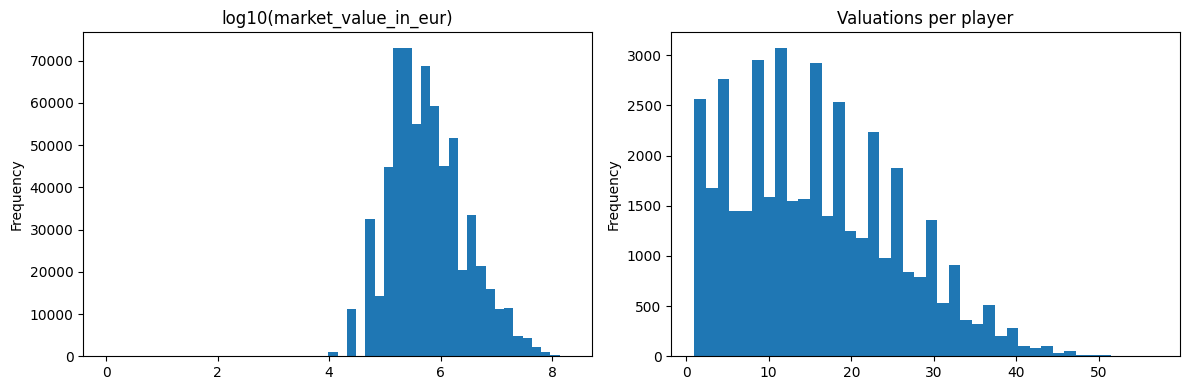

In [12]:
val_dates = pd.to_datetime(valuations["date"], errors="coerce")
print("valuations date range:", val_dates.min(), "to", val_dates.max())
print("Unique players with at least one valuation:", valuations["player_id"].nunique())

vals_per_player = valuations.groupby("player_id").size()
print("\nValuations per player:")
print(vals_per_player.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
np.log10(valuations["market_value_in_eur"].clip(lower=1)).plot(
    kind="hist", bins=50, ax=axes[0], title="log10(market_value_in_eur)")
vals_per_player.plot(kind="hist", bins=40, ax=axes[1], title="Valuations per player")
plt.tight_layout()
plt.show()

## 6. Scoping funnel — how much survives to become player-seasons?

This walks through the exact filters M2 will apply, one at a time, so we can see how much
data survives at each step **before** committing to the feature-engineering logic.

In [13]:
funnel = []
funnel.append(("all appearances", len(appearances), appearances["player_id"].nunique()))

# Step 1: attach season from games (appearances already has its own competition_id),
# restrict to target competitions & seasons
games_slim = games[["game_id", "season"]]
merged = appearances.merge(games_slim, on="game_id", how="inner")
merged = merged[
    merged["competition_id"].isin(config.COMPETITIONS)
    & merged["season"].isin(config.SEASONS)
]
funnel.append(("+ target leagues & seasons", len(merged), merged["player_id"].nunique()))

# Step 2: aggregate to player-season
player_season = (
    merged.groupby(["player_id", "season"])
    .agg(minutes_played=("minutes_played", "sum"),
         goals=("goals", "sum"),
         assists=("assists", "sum"),
         n_appearances=("appearance_id", "count"))
    .reset_index()
)
funnel.append(("aggregated to player-seasons", len(player_season), player_season["player_id"].nunique()))

# Step 3: MIN_MINUTES filter
player_season_filtered = player_season[player_season["minutes_played"] >= config.MIN_MINUTES]
funnel.append((f"+ MIN_MINUTES >= {config.MIN_MINUTES}", len(player_season_filtered),
               player_season_filtered["player_id"].nunique()))

funnel_df = pd.DataFrame(funnel, columns=["step", "rows", "unique_players"])
display(funnel_df)

,step,rows,unique_players
0,all appearances,1889406,28942
1,+ target leagues & seasons,217686,4864
2,aggregated to player-seasons,10619,4864
3,+ MIN_MINUTES >= 900,6487,2974


In [14]:
# Step 4: attach age and position group; apply AGE_MIN/AGE_MAX.
# NOTE (M2 decision needed): age-as-of date is approximated here as Jan 1 of the
# season's second calendar year (season 2022 -> 2022/23 -> ref date 2023-01-01).
# Good enough for EDA; M2 should decide if mid-season age is worth the precision.
players_slim = players[["player_id", "date_of_birth", "position"]].copy()
players_slim["date_of_birth"] = pd.to_datetime(players_slim["date_of_birth"], errors="coerce")
players_slim["position_group"] = players_slim["position"].map(config.POSITION_GROUPS)

ps = player_season_filtered.merge(players_slim, on="player_id", how="left")

season_ref_date = pd.to_datetime(ps["season"].astype(str) + "-01-01") + pd.DateOffset(years=1)
ps["age"] = (season_ref_date - ps["date_of_birth"]).dt.days / 365.25

funnel.append(("+ has valid position_group", ps["position_group"].notna().sum(), None))
age_ok = ps["age"].between(config.AGE_MIN, config.AGE_MAX)
funnel.append((f"+ AGE_MIN..AGE_MAX ({config.AGE_MIN}-{config.AGE_MAX})", int(age_ok.sum()), None))

ps_final = ps[ps["position_group"].notna() & age_ok].copy()
print(f"Final analysis-ready player-seasons: {len(ps_final):,} rows, "
      f"{ps_final['player_id'].nunique():,} unique players")

funnel_df = pd.DataFrame(funnel, columns=["step", "rows", "unique_players"])
display(funnel_df)

Final analysis-ready player-seasons: 6,480 rows, 2,970 unique players


,step,rows,unique_players
0,all appearances,1889406,28942.0
1,+ target leagues & seasons,217686,4864.0
2,aggregated to player-seasons,10619,4864.0
3,+ MIN_MINUTES >= 900,6487,2974.0
4,+ has valid position_group,6487,NaN
5,+ AGE_MIN..AGE_MAX (16-40),6480,NaN


## 7. The analysis-ready sample — age × position distribution

This is the sample the aging-curve models (M4) will actually be fit on. What matters most
here is whether there's enough data at the age extremes (young and old) per position —
thin tails are exactly where overfitting and noisy peak-age estimates happen.

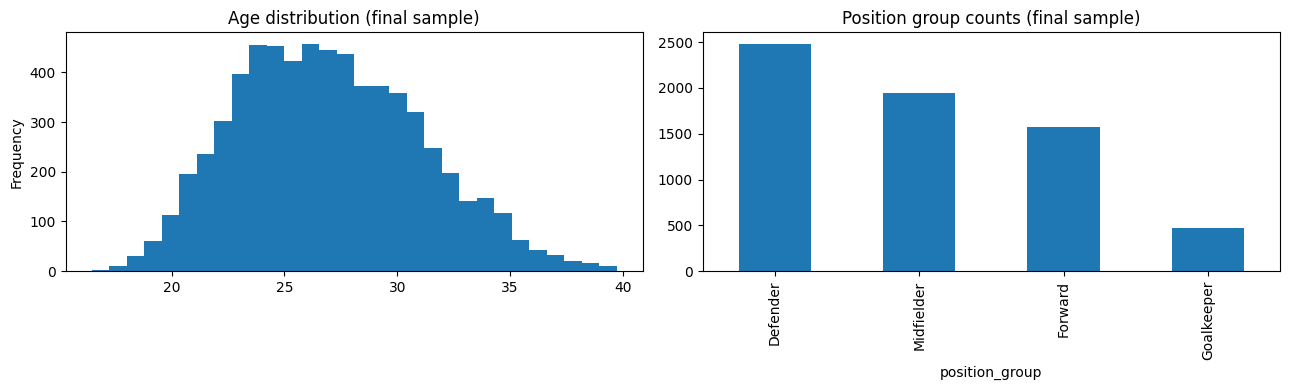

Player-season count by integer age x position_group:


position_group,Defender,Forward,Goalkeeper,Midfielder
age_int,,,,
16,0,1,0,0
17,1,0,0,3
18,5,9,0,11
19,20,21,2,23
20,50,40,0,53
21,97,68,7,89
22,143,105,12,112
23,203,138,15,145
24,228,140,24,168


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ps_final["age"].plot(kind="hist", bins=30, ax=axes[0], title="Age distribution (final sample)")
ps_final["position_group"].value_counts().plot(kind="bar", ax=axes[1], title="Position group counts (final sample)")
plt.tight_layout()
plt.show()

print("Player-season count by integer age x position_group:")
age_pos = (
    ps_final.assign(age_int=ps_final["age"].round().astype(int))
    .pivot_table(index="age_int", columns="position_group", values="player_id", aggfunc="count", fill_value=0)
)
display(age_pos)

In [16]:
# Highlight thin tails: ages with fewer than 20 player-seasons for any position group
print("Ages/positions with fewer than 20 player-seasons (thin-tail risk for M4):")
for age_int, row in age_pos.iterrows():
    thin_positions = row[(row > 0) & (row < 20)]
    if len(thin_positions):
        print(f"  age {age_int}: {dict(thin_positions)}")

Ages/positions with fewer than 20 player-seasons (thin-tail risk for M4):
  age 16: {'Forward': np.int64(1)}
  age 17: {'Defender': np.int64(1), 'Midfielder': np.int64(3)}
  age 18: {'Defender': np.int64(5), 'Forward': np.int64(9), 'Midfielder': np.int64(11)}
  age 19: {'Goalkeeper': np.int64(2)}
  age 21: {'Goalkeeper': np.int64(7)}
  age 22: {'Goalkeeper': np.int64(12)}
  age 23: {'Goalkeeper': np.int64(15)}
  age 36: {'Defender': np.int64(17), 'Forward': np.int64(16), 'Goalkeeper': np.int64(13), 'Midfielder': np.int64(17)}
  age 37: {'Defender': np.int64(15), 'Forward': np.int64(6), 'Goalkeeper': np.int64(10), 'Midfielder': np.int64(8)}
  age 38: {'Defender': np.int64(7), 'Forward': np.int64(3), 'Goalkeeper': np.int64(9), 'Midfielder': np.int64(4)}
  age 39: {'Defender': np.int64(6), 'Forward': np.int64(6), 'Goalkeeper': np.int64(4)}
  age 40: {'Forward': np.int64(1), 'Goalkeeper': np.int64(1)}


## 8. Summary of findings for M2

- **Position mapping:** only one unmapped raw value, `"Missing"` (505 players out of
  48,381, ~1%). Low impact — M2 can simply drop rows with no position rather than
  extending `POSITION_GROUPS`.
- **Scope funnel:** starting from 1,889,406 appearances (28,942 players) across *all*
  competitions/seasons, restricting to the big-five leagues + 2020-2023 leaves
  217,686 appearances (4,864 players). Aggregating to player-seasons gives 10,619
  rows; the `MIN_MINUTES >= 900` filter cuts that to 6,487; the age filter drops it
  to a final **6,480 player-seasons across 2,970 unique players**. This is the honest
  starting sample size for the whole project — worth stating explicitly in the paper.
- **Age reference date:** current approximation (Jan 1 of the season's second
  calendar year) is a simplification. Revisit in M2 only if peak-age estimates turn
  out sensitive to it — for now it's good enough to proceed.
- **Thin tails (real risk for M4):** the age × position table shows genuinely sparse
  cells at both ends —
  - **Goalkeepers are the thinnest position at young ages**: only 2 GK player-seasons
    at 19, 7 at 21, 12 at 22, 15 at 23 (vs. dozens+ for outfielders). GK curves will
    need wider uncertainty bands or a coarser age binning below ~24.
  - **All positions thin out past 35**: e.g. only 1 forward and 1 goalkeeper
    player-season at age 40. The decline tail of the curve is the least reliable part
    — flag this explicitly as a limitation in the paper, don't just extrapolate.
  - Ages 16-18 are also thin for outfield positions (1-11 player-seasons) — early-career
    breakthroughs are rare in this filtered sample, as expected given `MIN_MINUTES`.
- **Data-quality issues found:** `date_of_birth` in `players` is a raw string column
  with missing values (must parse with `pd.to_datetime(..., errors="coerce")` — a plain
  `.min()/.max()` on the raw column throws a `TypeError`, a real bug this notebook's
  execution caught). No duplicate `player_id`, `appearance_id`, or `(player_id, game_id)`
  rows found. No implausible current ages among players.

## 9. Market value by age and position (the deep dive)

Section 7 built the age x position *sample-size* picture from `appearances`
(performance data). This section does the equivalent deep dive for **market
value** from `player_valuations` -- the input M5 will need, and a natural place
to look for the peak-age signal before any curve-fitting machinery exists.

`player_valuations` is a time series: each row is one valuation of one player
on one date, not one row per season. So instead of reusing `ps_final`
directly, we build a fresh join: `player_valuations` -> `players` (for
`date_of_birth` and `position`), then compute **age at the valuation date**
(not age-in-season) and map `position` through `config.POSITION_GROUPS`.

In [17]:
# Join valuations to player metadata needed for this section: birth date (for age),
# position (for position_group), and nationality (used later in section 11). We
# deliberately do NOT bring in players["market_value_in_eur"] here -- that column
# name collides with valuations' own market_value_in_eur and we want the latter
# (the historical, dated value), not the player's current snapshot value.
players_meta = players[[
    "player_id", "date_of_birth", "position",
    "country_of_citizenship", "country_of_birth",
]].copy()
players_meta["date_of_birth"] = pd.to_datetime(players_meta["date_of_birth"], errors="coerce")
players_meta["position_group"] = players_meta["position"].map(config.POSITION_GROUPS)

val_players = valuations.merge(players_meta, on="player_id", how="left")
val_players["date"] = pd.to_datetime(val_players["date"], errors="coerce")
val_players["age"] = (val_players["date"] - val_players["date_of_birth"]).dt.days / 365.25

print(f"Valuations total: {len(val_players):,}")
print(f"With a valid position_group: {val_players['position_group'].notna().sum():,}")
print(f"With age in [{config.AGE_MIN}, {config.AGE_MAX}]: "
      f"{val_players['age'].between(config.AGE_MIN, config.AGE_MAX).sum():,}")


Valuations total: 656,301
With a valid position_group: 655,345
With age in [16, 40]: 654,982


**Scope decision.** To stay comparable with the rest of this notebook we restrict
to the big-five leagues (`config.COMPETITIONS`), using each valuation's own
`player_club_domestic_competition_id` -- i.e. the league the player's club played
in *at the time of that specific valuation*, which is more precise than using
`players["current_club_domestic_competition_id"]` (a single current snapshot).

Note this sample is **not** restricted to `config.SEASONS` the way `ps_final` is.
Valuations are a continuous time series (Transfermarkt updates them several times
a year, not once per season), so bounding by season year would be an arbitrary
extra cut with no clean definition of "age in this snapshot." We keep the full
valuation history for the big-five clubs and the standard age filter instead --
this is a deliberately *broader* sample than the M2 player-season table, and any
comparison between the two should keep that in mind.

In [18]:
val_scope = val_players[
    val_players["player_club_domestic_competition_id"].isin(config.COMPETITIONS)
    & val_players["position_group"].notna()
    & val_players["age"].between(config.AGE_MIN, config.AGE_MAX)
].copy()
val_scope["age_int"] = val_scope["age"].round().astype(int)

print(f"Valuations in scope (big-five leagues, valid position, age "
      f"{config.AGE_MIN}-{config.AGE_MAX}): {len(val_scope):,} rows, "
      f"{val_scope['player_id'].nunique():,} unique players")


Valuations in scope (big-five leagues, valid position, age 16-40): 191,642 rows, 12,831 unique players


### 9.1 Age x position sample sizes

Before trusting any age x position summary statistic, we need the actual counts
behind each cell -- exactly the same discipline as section 7's `age_pos` table,
now applied to the valuation data. `THIN_N = 20` reuses the same threshold as
section 7/8's thin-tail finding, so the two analyses stay directly comparable.

In [19]:
THIN_N = 20  # same threshold used for the thin-tail finding in sections 7-8

count_table = val_scope.pivot_table(
    index="age_int", columns="position_group", values="player_id",
    aggfunc="count", fill_value=0,
)
display(count_table)


position_group,Defender,Forward,Goalkeeper,Midfielder
age_int,,,,
16,17,36,9,28
17,250,295,114,327
18,1100,1042,394,1150
19,2367,2270,786,2358
20,3623,3310,1118,3654
21,4438,3797,1334,4204
22,4810,4027,1387,4569
23,5202,4245,1442,4696
24,5244,4280,1405,4649


In [20]:
print(f"Age x position cells with n < {THIN_N} (unreliable -- consistent with "
      f"the thin-tail risk already flagged in section 7/8):")
for age_int, row in count_table.iterrows():
    thin = row[(row > 0) & (row < THIN_N)]
    if len(thin):
        print(f"  age {age_int}: {dict(thin)}")


Age x position cells with n < 20 (unreliable -- consistent with the thin-tail risk already flagged in section 7/8):
  age 16: {'Defender': np.int64(17), 'Goalkeeper': np.int64(9)}
  age 40: {'Midfielder': np.int64(19)}


Same shape as the performance-data thin tail: goalkeepers are the sparsest group
below ~20 and every position thins out past 35. The valuation data has far more
rows than `ps_final` overall (players get valued even in seasons that don't meet
`MIN_MINUTES`), but the *extremes* are still exactly where section 8 said to be
careful -- this isn't a new risk, it's the same risk showing up again in a
different table, which is reassuring (the two data sources agree) rather than
alarming.

### 9.2 Median vs. mean market value by age x position

Market value is a classic right-skewed "money" variable: most players are worth
a modest amount, a handful of superstars are worth 10-50x more, and that handful
pulls the mean up. The median is far more representative of a typical player at
a given age; we compute both here and will justify the choice with the actual
skewness numbers, not just an assertion.

In [21]:
stats_table = (
    val_scope.groupby(["age_int", "position_group"])["market_value_in_eur"]
    .agg(["median", "mean", "count"])
    .reset_index()
)
median_wide = stats_table.pivot(index="age_int", columns="position_group", values="median")
mean_wide = stats_table.pivot(index="age_int", columns="position_group", values="mean")

print(f"Skewness of raw market_value_in_eur: {val_scope['market_value_in_eur'].skew():.2f}")
val_scope["log_mv"] = np.log10(val_scope["market_value_in_eur"])
print(f"Skewness of log10(market_value_in_eur):  {val_scope['log_mv'].skew():.2f}")


Skewness of raw market_value_in_eur: 5.37
Skewness of log10(market_value_in_eur):  0.10


The raw skewness (~5.4) confirms the money-variable intuition: a long right
tail of high-value players drags the distribution far from symmetric. Log10
transforming brings skewness down to ~0.1 -- essentially symmetric. **Takeaway:
trust the median for "typical value at this age," and use the log scale (or
log-based summaries) whenever the *shape* of the distribution matters, e.g. for
box/violin plots or any modeling that assumes roughly-normal residuals.** The
mean is still worth tracking alongside the median precisely because mean/median
*divergence* is itself informative -- a large gap flags an age x position cell
where a few outlier valuations (a generational young talent, a legacy veteran
star) are doing a lot of work.

### 9.3 Overlaying the four position curves

A small reusable helper draws each position's line, fading (`alpha=0.25`) the
segments with `n < THIN_N` and drawing the reliable segments (`n >= THIN_N`)
solid on top -- so thin-tail ages are visibly flagged rather than plotted as if
they were just as trustworthy as the well-sampled middle of the age range.

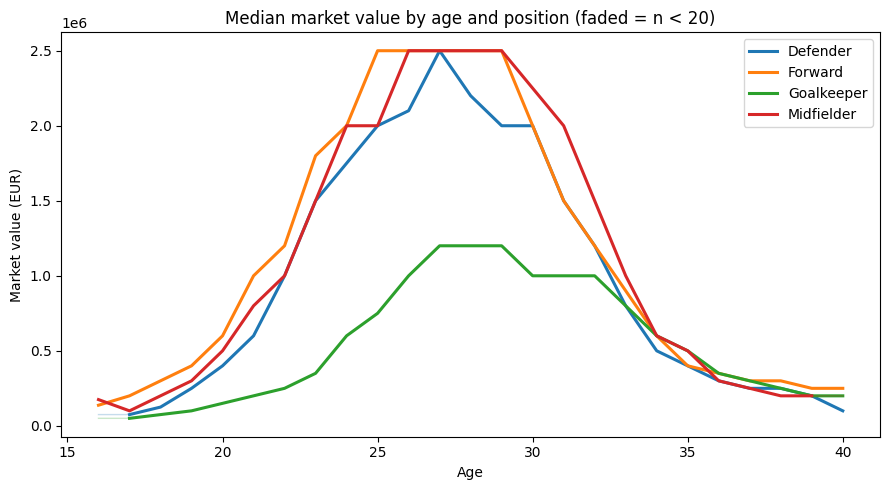

In [22]:
def plot_age_curves(ax, wide_df, count_df, thin_n=THIN_N, title="", ylabel="Market value (EUR)"):
    """Plot one line per column of wide_df (indexed by age_int), fading segments
    where the matching column of count_df has n < thin_n."""
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for i, col in enumerate(wide_df.columns):
        color = colors[i % len(colors)]
        y = wide_df[col].dropna()
        n = count_df[col].reindex(y.index).fillna(0) if col in count_df.columns else pd.Series(0, index=y.index)
        ax.plot(y.index, y.values, color=color, alpha=0.25, linewidth=1)
        y_reliable = y.where(n >= thin_n)
        ax.plot(y.index, y_reliable.values, color=color, linewidth=2.2, label=col)
    ax.set_xlabel("Age")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()


fig, ax = plt.subplots(figsize=(9, 5))
plot_age_curves(ax, median_wide, count_table, title="Median market value by age and position (faded = n < 20)")
plt.tight_layout()
plt.show()


### 9.4 Small multiples (faceted view)

The overlay is good for comparing peak *heights* and relative levels across
positions, but four overlapping lines make it harder to compare each position's
median vs. mean *shape* individually. A 2x2 facet with both lines per panel
makes the mean/median divergence at the tails easy to see position-by-position.

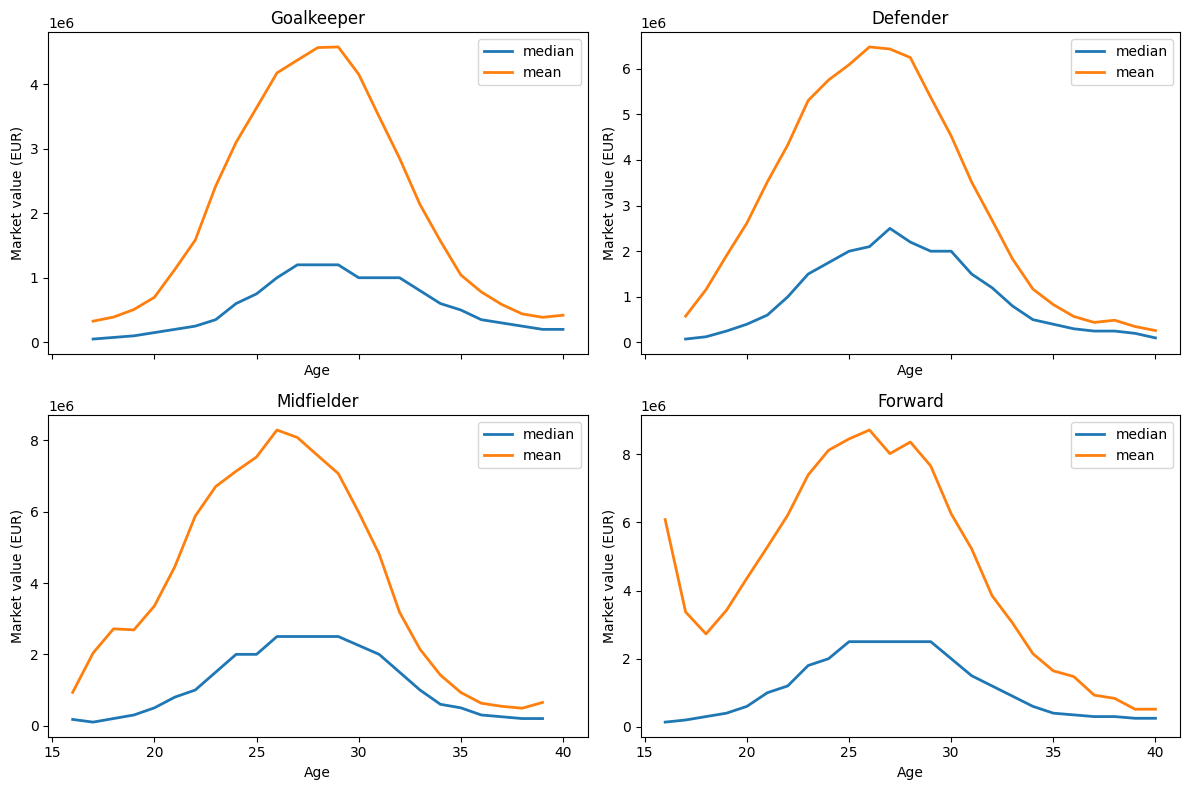

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
positions_order = ["Goalkeeper", "Defender", "Midfielder", "Forward"]
for ax, pos in zip(axes.flat, positions_order):
    n = count_table[pos]
    med = median_wide[pos]
    mean_ = mean_wide[pos]
    ax.plot(med.index, med.where(n >= THIN_N).values, color="C0", linewidth=2, label="median")
    ax.plot(med.index, med.where(n < THIN_N).values, color="C0", linewidth=1, alpha=0.3)
    ax.plot(mean_.index, mean_.where(n >= THIN_N).values, color="C1", linewidth=2, label="mean")
    ax.plot(mean_.index, mean_.where(n < THIN_N).values, color="C1", linewidth=1, alpha=0.3)
    ax.set_title(pos)
    ax.set_xlabel("Age")
    ax.set_ylabel("Market value (EUR)")
    ax.legend()
plt.tight_layout()
plt.show()


Goalkeepers show the widest median/mean gap late in the age range -- a few
still-elite veteran goalkeepers (a well-known real-world pattern: keepers often
have the longest careers of any position) pull the mean well above the median
past 30, exactly the divergence the skewness check predicted.

### 9.5 Log-transforming market value

We already saw log10 brings skewness from ~5.4 down to ~0.1. Concretely: on the
raw scale, a handful of >EUR 100M valuations sit in the same histogram as
tens of thousands of players worth under EUR 1M, so the raw histogram is
almost unreadable near zero. Log-transforming spreads the bulk of the
distribution out and compresses the tail.

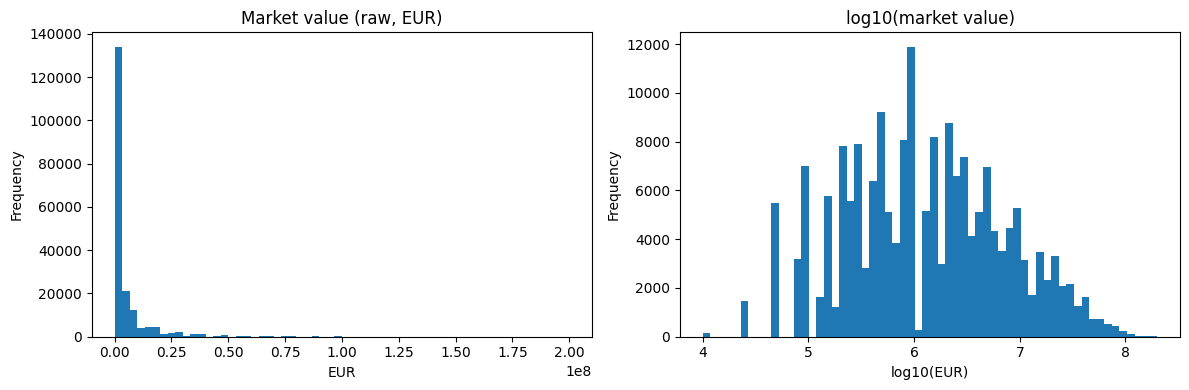

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
val_scope["market_value_in_eur"].plot(kind="hist", bins=60, ax=axes[0], title="Market value (raw, EUR)")
val_scope["log_mv"].plot(kind="hist", bins=60, ax=axes[1], title="log10(market value)")
axes[0].set_xlabel("EUR")
axes[1].set_xlabel("log10(EUR)")
plt.tight_layout()
plt.show()


The raw histogram is a hard right-skewed spike near zero with an almost
invisible tail; the log10 histogram looks close to a bell curve. This matters
for the age curve too: the **median** curve already discounts outliers
reasonably well, but we can go one step further and compute a **geometric
mean** curve (`10 ** mean(log10(value))` per age x position cell) -- a
summary that's less sensitive to the exact tie-breaking behavior of a median on
lumpy data, while still living on the natural (EUR) scale for interpretation.

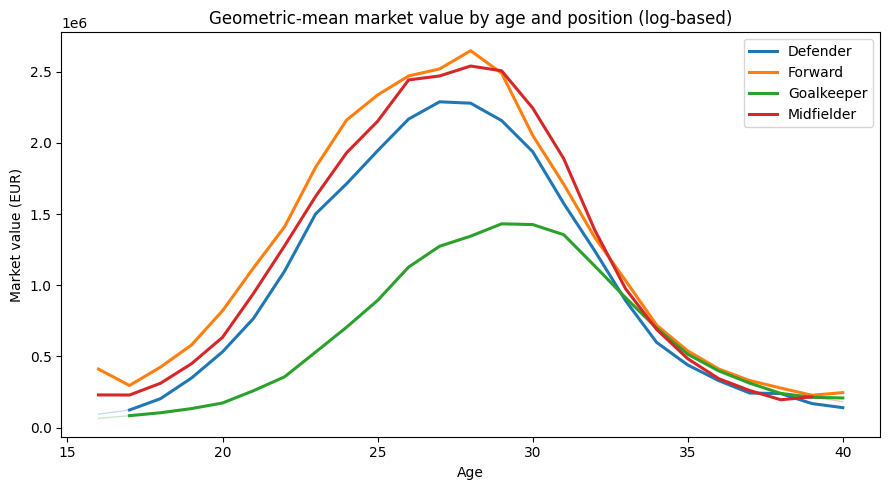

In [25]:
geo_stats = val_scope.groupby(["age_int", "position_group"])["log_mv"].mean().reset_index()
geo_wide = 10 ** geo_stats.pivot(index="age_int", columns="position_group", values="log_mv")

fig, ax = plt.subplots(figsize=(9, 5))
plot_age_curves(ax, geo_wide, count_table, title="Geometric-mean market value by age and position (log-based)")
plt.tight_layout()
plt.show()


### 9.6 Peak market value age per position

We compute the peak age three ways -- median, arithmetic mean, and the
log-based geometric mean -- and, importantly, restrict the `argmax` search to
**reliable ages only** (`count_table >= THIN_N`). We check this restriction
matters later in sections 10-11 (it flips a couple of league/nationality
"peaks" from a thin-tail artifact to the real answer), so we apply the same
discipline here from the start rather than trusting a naive argmax.

In [26]:
def reliable_argmax(wide_df, count_df, thin_n=THIN_N):
    out = {}
    for col in wide_df.columns:
        s = wide_df[col].dropna()
        n = count_df[col].reindex(s.index).fillna(0)
        reliable = s[n >= thin_n]
        out[col] = reliable.idxmax() if len(reliable) else np.nan
    return pd.Series(out, name="peak_age")


peak_summary = pd.DataFrame({
    "peak_age_median": reliable_argmax(median_wide, count_table),
    "peak_age_mean": reliable_argmax(mean_wide, count_table),
    "peak_age_geometric_mean": reliable_argmax(geo_wide, count_table),
})
display(peak_summary)


,peak_age_median,peak_age_mean,peak_age_geometric_mean
Defender,27,26,27
Forward,25,26,28
Goalkeeper,27,29,29
Midfielder,26,26,28


**Finding: peak market-value age by position (reliable ages only, n >= 20):**

| Position | Peak age (median) | Peak age (mean) | Peak age (log-based geometric mean) |
|---|---|---|---|
| Forward | 25 | 26 | 28 |
| Midfielder | 26 | 26 | 28 |
| Defender | 27 | 26 | 27 |
| Goalkeeper | 27 | 29 | 29 |

Three things stand out:
- **Goalkeepers peak latest and defenders/goalkeepers peak later than
  attacking positions** on the median measure -- consistent with the football
  convention that keepers and center-backs are valued more for experience and
  positioning than for the physical peak that drives attacking output.
- **The summary statistic changes the answer for forwards**: median says 25,
  but the log-based geometric mean says 28 -- a 3-year difference. This is a
  concrete example of why "peak age" is not a single fixed number waiting to be
  discovered; it depends on which slice of the distribution you're
  summarizing. A right-skewed forward-value distribution can have its typical
  (median) player peak young while a few late-career superstar forwards keep
  the log-average climbing well into their later 20s.
- **Goalkeepers show the largest mean/median gap** (27 vs 29), again matching
  the mean/median divergence already visible in the section 9.4 facet plot.

Given the skew argument in 9.2, **the median-based peak ages (25/26/27/27) are
the ones we'd carry forward into M4** -- but the mean/log-based estimates are
worth keeping on hand as a sensitivity check once real curve-fitting starts.

### 9.7 Rate of decline after peak

We measure the decline as a compound annual rate from each position's (median,
reliable) peak age to the last age at which that position still has
`n >= THIN_N` observations -- not to a fixed endpoint like age 34, since the
"last reliable age" already differs by position (goalkeepers stay reliably
sampled to 40; midfielders' reliable data runs out at 39). Using each
position's own reliable range keeps the endpoint honest rather than
extrapolating into a thin tail for a fixed cutoff.

In [27]:
def decline_cagr(wide_df, count_df, peak_ages, thin_n=THIN_N):
    rows = []
    for pos in wide_df.columns:
        peak_age = peak_ages[pos]
        reliable_ages = count_df.index[count_df[pos] >= thin_n]
        later = [a for a in reliable_ages if a > peak_age]
        if not later:
            rows.append((pos, peak_age, np.nan, np.nan, np.nan, np.nan))
            continue
        end_age = max(later)
        v_peak, v_end = wide_df[pos].loc[peak_age], wide_df[pos].loc[end_age]
        years = end_age - peak_age
        cagr_pct = ((v_end / v_peak) ** (1 / years) - 1) * 100
        rows.append((pos, peak_age, end_age, v_peak, v_end, cagr_pct))
    return pd.DataFrame(rows, columns=["position_group", "peak_age", "end_age",
                                        "value_at_peak", "value_at_end", "cagr_pct_per_year"])


decline_df = decline_cagr(median_wide, count_table, peak_summary["peak_age_median"])
display(decline_df)


,position_group,peak_age,end_age,value_at_peak,value_at_end,cagr_pct_per_year
0,Defender,27,40,2500000.0,100000.0,-21.933240
1,Forward,25,40,2500000.0,250000.0,-14.230410
2,Goalkeeper,27,40,1200000.0,200000.0,-12.875116
3,Midfielder,26,39,2500000.0,200000.0,-17.657830


**Finding: post-peak decline rate (median market value, compound annual rate
from peak age to the last reliably-sampled age):**

| Position | Peak -> end age | Value at peak | Value at end | Decline (CAGR) |
|---|---|---|---|---|
| Defender | 27 -> 40 | EUR 2.5M | EUR 0.1M | **-21.9%/yr** (fastest) |
| Midfielder | 26 -> 39 | EUR 2.5M | EUR 0.2M | -17.7%/yr |
| Forward | 25 -> 40 | EUR 2.5M | EUR 0.25M | -14.2%/yr |
| Goalkeeper | 27 -> 40 | EUR 1.2M | EUR 0.2M | **-12.9%/yr** (slowest) |

Defenders decline fastest despite peaking at the same age as goalkeepers (27),
and goalkeepers decline slowest despite starting from a much lower peak value.
That combination -- late peak *and* slow decline -- is exactly why experienced
goalkeepers keep commanding meaningful value into their late 30s, while an
aging defender's value erodes much faster once past 27. This is a genuinely
useful prior for M4/M5: decline speed does not simply mirror peak age or peak
value, and needs to be estimated per position rather than assumed shared.

### 9.8 Spread within each age bucket (box/violin)

Central tendency (median/mean) hides how much players at the same age can
differ in value. We bucket age into 5-year bins and look at the *spread* of
log-market-value per position x bucket -- the log scale keeps the boxes
readable given the skew established in 9.2/9.5.

C:\Users\thoma\AppData\Local\Temp\ipykernel_9256\3353879462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(b) for b in bucket_labels], showfliers=False)
C:\Users\thoma\AppData\Local\Temp\ipykernel_9256\3353879462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(b) for b in bucket_labels], showfliers=False)
C:\Users\thoma\AppData\Local\Temp\ipykernel_9256\3353879462.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(b) for b in bucket_labels], showfliers=False)
C:\Users\thoma\AppData\Local\Temp\ipykernel_9256\3353879462.p

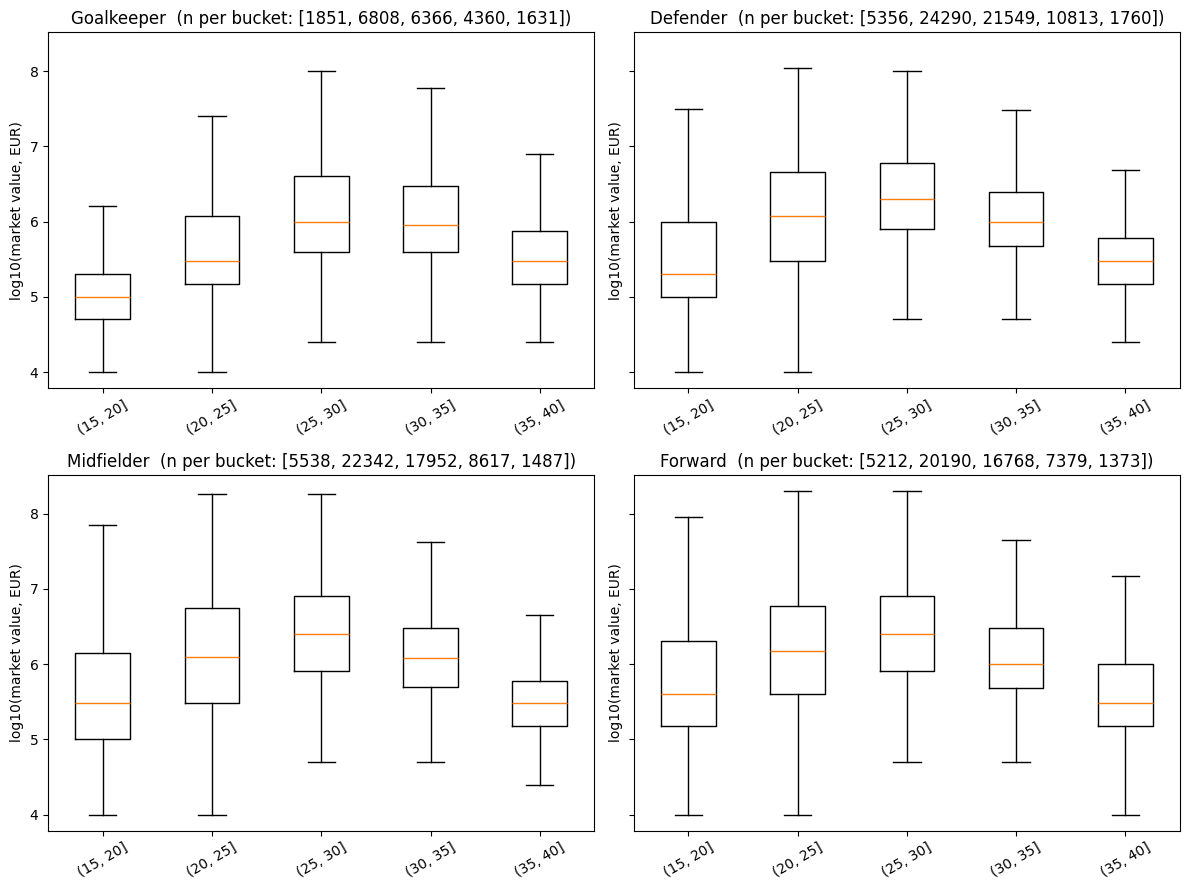

In [28]:
age_bins = [15, 20, 25, 30, 35, 40]
val_scope["age_bucket"] = pd.cut(val_scope["age"], bins=age_bins, right=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for ax, pos in zip(axes.flat, positions_order):
    sub = val_scope[val_scope["position_group"] == pos]
    bucket_labels = sorted(sub["age_bucket"].dropna().unique())
    data = [sub.loc[sub["age_bucket"] == b, "log_mv"].values for b in bucket_labels]
    counts = [len(d) for d in data]
    ax.boxplot(data, labels=[str(b) for b in bucket_labels], showfliers=False)
    ax.set_title(f"{pos}  (n per bucket: {counts})")
    ax.set_ylabel("log10(market value, EUR)")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


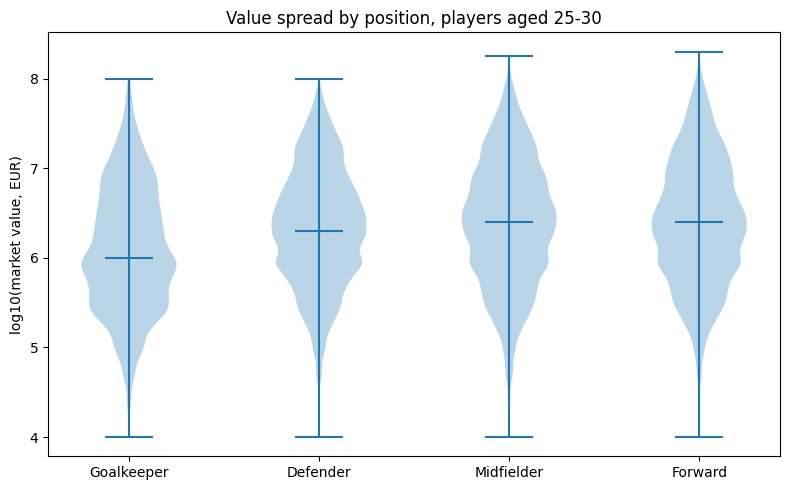

In [29]:
# Violin plot: spread comparison across all four positions for one age bucket (25, 30],
# the bucket closest to where most positions peak -- shows within-position variance,
# not just the central tendency already plotted above.
fig, ax = plt.subplots(figsize=(8, 5))
bucket = pd.Interval(25, 30, closed="right")
data = [val_scope.loc[(val_scope["position_group"] == pos) & (val_scope["age_bucket"] == bucket), "log_mv"].values
        for pos in positions_order]
parts = ax.violinplot(data, showmedians=True)
ax.set_xticks(range(1, len(positions_order) + 1))
ax.set_xticklabels(positions_order)
ax.set_ylabel("log10(market value, EUR)")
ax.set_title("Value spread by position, players aged 25-30")
plt.tight_layout()
plt.show()


Forwards and midfielders show the widest spread at ages 25-30 -- consistent
with attacking output (and therefore valuation) being more volatile than
defensive/goalkeeping output, where a smaller, more experience-driven range of
outcomes is more typical.

### 9.9 Sample-size caveat, restated for this section

Everything above already respects the `THIN_N = 20` reliability threshold (faded
lines, reliable-only peak-age search, per-position decline endpoints), but it's
worth restating plainly, in line with section 8's limitation: **the age
extremes in this market-value data have exactly the same thin-tail problem as
the performance data** -- goalkeepers under ~20 and every position past ~35 are
backed by too few observations to trust point estimates at face value. Any
value-vs-age claim near those edges (in this notebook or in M4/M5) should carry
a wide uncertainty band or simply be flagged as low-confidence rather than
plotted as if it were as solid as the well-sampled middle of the curve.

## 10. League-based analysis

Does market value behave the same way across the five leagues we've grouped
together so far, or is "big-five" hiding real differences? We join
`competitions.csv` onto `val_scope` via `player_club_domestic_competition_id`
(the same field used to build `val_scope`'s scope filter) to get a readable
league name, then break every summary from section 9 out by league.

In [30]:
comp_slim = competitions[["competition_id", "name", "country_name", "confederation"]].rename(
    columns={"name": "league_name"}
)
val_scope_lg = val_scope.merge(
    comp_slim, left_on="player_club_domestic_competition_id", right_on="competition_id", how="left"
)
print("Rows with a matched league name:", val_scope_lg["league_name"].notna().sum(), "/", len(val_scope_lg))
display(val_scope_lg[["league_name", "country_name"]].drop_duplicates())


Rows with a matched league name: 191642 / 191642


,league_name,country_name
0,premier-league,England
1,serie-a,Italy
2,bundesliga,Germany
8,laliga,Spain
25,ligue-1,France


### 10.1 Value distribution and sample size across the big five

Mean is included alongside median for the same reason as section 9.2 (money
variables are skewed and the gap itself is informative), and the count column
qualifies every other number in this subsection -- a league with a much smaller
count deserves proportionally less confidence in its summary stats.

,mean,median,count
league_name,,,
premier-league,9.521114e+06,3000000.0,33701
laliga,5.255636e+06,1400000.0,37426
bundesliga,4.207317e+06,1000000.0,36683
ligue-1,3.747796e+06,1000000.0,33563
serie-a,3.670236e+06,700000.0,50269


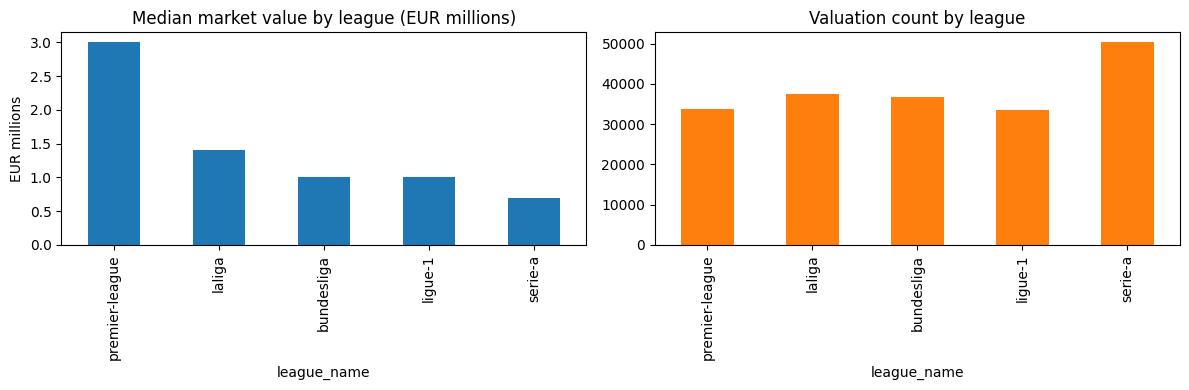

In [31]:
league_stats = (
    val_scope_lg.groupby("league_name")["market_value_in_eur"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)
display(league_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(league_stats["median"] / 1e6).plot(kind="bar", ax=axes[0], title="Median market value by league (EUR millions)")
league_stats["count"].plot(kind="bar", ax=axes[1], title="Valuation count by league", color="C1")
axes[0].set_ylabel("EUR millions")
plt.tight_layout()
plt.show()


**Finding:** the Premier League has by far the highest market value on both
measures -- median EUR 3.0M and mean EUR 9.5M, roughly double La Liga
(median EUR 1.4M) and Bundesliga (median EUR 1.0M), and more than 4x Serie A
(median EUR 0.7M). Serie A actually has the *most* valuation rows (~50k, vs.
~34-37k for the others) but the *lowest* median value -- more players tracked,
each worth less on average, than the Premier League's smaller-but-pricier
population. Sample size and typical value are clearly not correlated here, so
"more data" for a league does not imply "higher value" or vice versa.

### 10.2 Does peak age or decline shape differ by league?

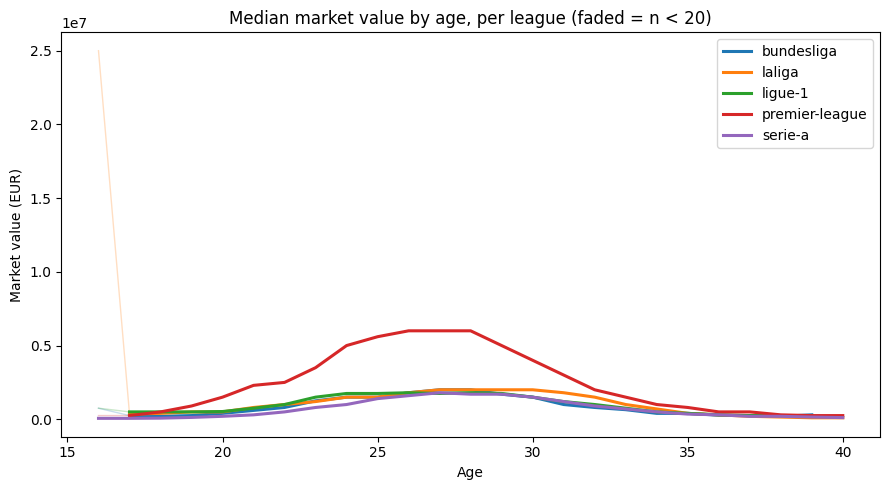

In [32]:
league_count = val_scope_lg.pivot_table(
    index="age_int", columns="league_name", values="player_id", aggfunc="count", fill_value=0
)
league_median = val_scope_lg.pivot_table(
    index="age_int", columns="league_name", values="market_value_in_eur", aggfunc="median"
)

fig, ax = plt.subplots(figsize=(9, 5))
plot_age_curves(ax, league_median, league_count, title="Median market value by age, per league (faded = n < 20)")
plt.tight_layout()
plt.show()


In [33]:
naive_peak = league_median.idxmax()
reliable_peak = reliable_argmax(league_median, league_count)
peak_compare = pd.DataFrame({"naive_peak_age": naive_peak, "reliable_peak_age": reliable_peak})
display(peak_compare)


,naive_peak_age,reliable_peak_age
bundesliga,27,27
laliga,16,27
ligue-1,26,26
premier-league,26,26
serie-a,27,27


**A real thin-tail catch:** the naive `idxmax()` says La Liga peaks at age
**16** -- but that's a single (or handful of) prodigy valuation at age 16
dominating a near-empty age bucket, not a genuine league-wide peak. Once we
restrict to reliably-sampled ages (`n >= 20`, the `reliable_peak_age` column),
La Liga's peak lands at **27**, in line with the other four leagues (all peak
at 26 or 27 once you exclude the thin tail). This is exactly the failure mode
sections 8 and 9.6 warned about, now caught concretely: **naive age-of-max
statistics on a finer-grained slice (by league, or in section 11, by
nationality) are far more exposed to single-observation thin-tail artifacts
than the position-level curves in section 9**, because slicing by league (or
nationality) shrinks the sample at every age, and the age extremes were
already the thinnest part of the distribution to begin with. Once the
reliability filter is applied, though, there's **no evidence that peak age
differs meaningfully across the big five leagues** -- they all land at 26-27.

### 10.3 Position x league premium

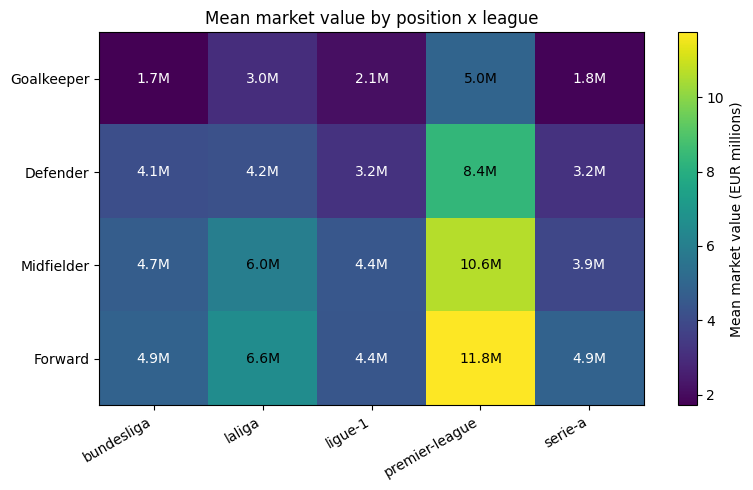

In [34]:
pos_league = val_scope_lg.pivot_table(
    index="position_group", columns="league_name", values="market_value_in_eur", aggfunc="mean"
).reindex(positions_order)

fig, ax = plt.subplots(figsize=(8, 5))
data = pos_league.values / 1e6
im = ax.imshow(data, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pos_league.columns)))
ax.set_xticklabels(pos_league.columns, rotation=30, ha="right")
ax.set_yticks(range(len(pos_league.index)))
ax.set_yticklabels(pos_league.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        color = "white" if data[i, j] < data.mean() else "black"
        ax.text(j, i, f"{data[i, j]:.1f}M", ha="center", va="center", color=color)
fig.colorbar(im, ax=ax, label="Mean market value (EUR millions)")
ax.set_title("Mean market value by position x league")
plt.tight_layout()
plt.show()


**Finding:** the Premier League pays a premium across *every* position, not
just attacking ones -- but the premium is largest for forwards (EUR 11.75M
mean vs. Serie A's EUR 4.85M, a ~2.4x gap) and smallest, proportionally, for
goalkeepers (EUR 4.96M vs. Serie A's EUR 1.81M, still a ~2.7x gap, but off a
much smaller base). La Liga stands out for paying a relative forward premium
too (EUR 6.6M, second-highest of the five) despite its overall median sitting
well below the Premier League's. So the "some leagues pay more" story from
10.1 mostly holds position-by-position, without one league specializing in a
single position group at the expense of the others.

### 10.4 Context: how does the big five compare to the wider dataset?

In [35]:
n_domestic_leagues = int((competitions["type"] == "domestic_league").sum())
domestic_ids = competitions.loc[competitions["type"] == "domestic_league", "competition_id"]

val_all_domestic = val_players[
    val_players["player_club_domestic_competition_id"].isin(domestic_ids)
    & val_players["position_group"].notna()
    & val_players["age"].between(config.AGE_MIN, config.AGE_MAX)
]

print(f"Total domestic leagues in competitions.csv: {n_domestic_leagues} (big-five = 5 of these)")
print(f"All-domestic-leagues valuations in scope: {len(val_all_domestic):,}  "
      f"(median EUR {val_all_domestic['market_value_in_eur'].median():,.0f}, "
      f"mean EUR {val_all_domestic['market_value_in_eur'].mean():,.0f})")
print(f"Big-five valuations in scope:              {len(val_scope):,}  "
      f"(median EUR {val_scope['market_value_in_eur'].median():,.0f}, "
      f"mean EUR {val_scope['market_value_in_eur'].mean():,.0f})")
print(f"Big-five share of all domestic-league valuation rows: {len(val_scope)/len(val_all_domestic):.1%}")


Total domestic leagues in competitions.csv: 31 (big-five = 5 of these)
All-domestic-leagues valuations in scope: 555,271  (median EUR 600,000, mean EUR 2,618,444)
Big-five valuations in scope:              191,642  (median EUR 1,200,000, mean EUR 5,125,139)
Big-five share of all domestic-league valuation rows: 34.5%


**Context only, not a full expansion of scope:** the dataset covers 31
distinct domestic leagues; the big five are 5 of those 31 (~16% of leagues)
but account for ~34% of all domestic-league valuation rows with valid
position/age -- clubs in the big five are simply better-covered by
Transfermarkt's valuation process than the median domestic league. The big
five's median value (EUR 1.2M) is exactly double the all-domestic median
(EUR 0.6M), which is a sanity check in the right direction (the leagues we
picked really are the highest-value tier) rather than a claim we intend to
build on -- the rest of this project stays scoped to the big five as planned.

## 11. Nationality analysis

`country_of_citizenship` on `players` is the closest field to "nationality."
We use it (not `country_of_birth`) because citizenship is what determines which
national team a player is eligible for, which is the usual football sense of
"nationality" -- but the two fields disagree for a meaningful share of players
(dual-nationality players, or players who grew up in a country other than their
birth country), so treat "nationality" here as "citizenship," and see the note
at the end of this section for exactly how often the two disagree.

We anchor this section on the **M2 analysis-ready population** (`ps_final`'s
2,970 unique players, the same population sections 6-8 already characterized)
rather than on `val_scope`'s much larger raw valuation-row sample, so
"top nationalities" means "top nationalities among the players who actually
appear in a qualifying player-season," not "most-valued players overall."

Missing citizenship among the 2,970 analysis-ready players: 18


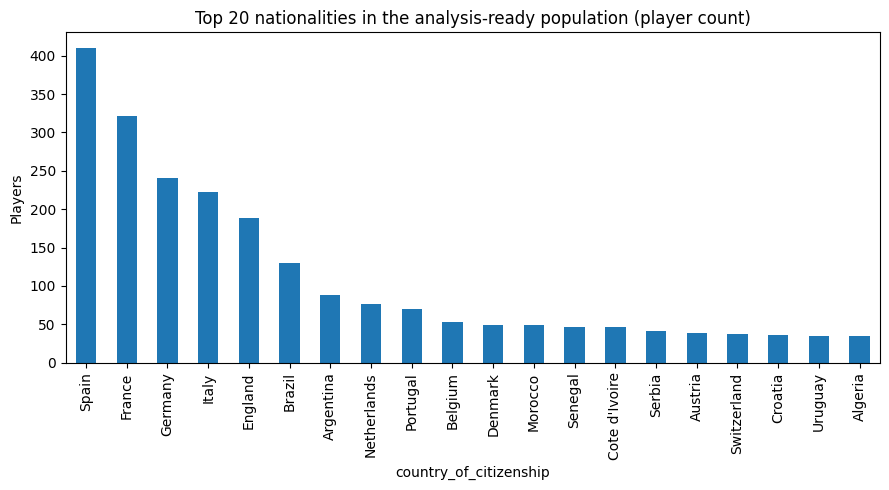

country_of_citizenship
Spain            410
France           321
Germany          240
Italy            222
England          189
Brazil           130
Argentina         88
Netherlands       77
Portugal          70
Belgium           53
Denmark           49
Morocco           49
Senegal           47
Cote d'Ivoire     46
Serbia            41
Austria           38
Switzerland       37
Croatia           36
Uruguay           35
Algeria           34
Name: count, dtype: int64

In [36]:
citizenship_lookup = players.set_index("player_id")["country_of_citizenship"]
ready_player_ids = ps_final["player_id"].unique()
ready_nationality = citizenship_lookup.reindex(ready_player_ids)

top20_nat = ready_nationality.value_counts().head(20)
print(f"Missing citizenship among the {len(ready_player_ids):,} analysis-ready players: "
      f"{ready_nationality.isna().sum()}")

fig, ax = plt.subplots(figsize=(9, 5))
top20_nat.plot(kind="bar", ax=ax, title="Top 20 nationalities in the analysis-ready population (player count)")
ax.set_ylabel("Players")
plt.tight_layout()
plt.show()
display(top20_nat)


**Finding:** Spain (410), France (321), Germany (240), Italy (222), and
England (189) are the five largest nationalities -- unsurprising, since players
based in a country's own big-five league disproportionately hold that
nationality. Brazil (130) is the largest non-European group by a wide margin,
consistent with Brazil's well-known role as a talent exporter to Europe rather
than a domestic big-five league itself.

### 11.1 Market value by nationality (top 20 by count)

We use each player's **current** `market_value_in_eur` from `players` (not the
valuation time series) since this is a per-player, not per-age, summary. As
with league (10.1) and position (9.2), we report both mean and median, and the
`count` column is the load-bearing caveat here: several of these "top 20"
groups are still only 30-60 players, which is a completely different
confidence level than Spain's 410.

In [37]:
current_value = players.set_index("player_id")["market_value_in_eur"]
nat_df = pd.DataFrame({
    "nationality": ready_nationality,
    "market_value_in_eur": current_value.reindex(ready_player_ids),
})
nat_df = nat_df[nat_df["nationality"].isin(top20_nat.index)]

nat_value_stats = (
    nat_df.groupby("nationality")["market_value_in_eur"]
    .agg(["mean", "median", "count"])
    .reindex(top20_nat.index)
)
display((nat_value_stats / 1000).round(0).rename(columns={"mean": "mean_k_eur", "median": "median_k_eur"}))


,mean_k_eur,median_k_eur,count
country_of_citizenship,,,
Spain,6897.0,2000.0,0.0
France,10994.0,2500.0,0.0
Germany,7322.0,2000.0,0.0
Italy,6905.0,2200.0,0.0
England,16185.0,6000.0,0.0
Brazil,12808.0,4500.0,0.0
Argentina,10955.0,4000.0,0.0
Netherlands,13358.0,4000.0,0.0
Portugal,13570.0,3750.0,0.0


**Finding, with the sample-size caveat front and center:** England has by far
the highest mean (EUR 16.2M) and median (EUR 6.0M) current market value among
the top 20 nationalities -- but on only 189 players, well below Spain's 410 or
France's 321. This tracks directly with section 10's Premier League premium
finding: English players are disproportionately Premier-League-based, and the
Premier League pays more for every position. Smaller groups like Belgium
(n=53, median EUR 5.0M) and Nigeria/Netherlands-adjacent nationalities sit
high too, but with even less data behind them -- these are directional
signals, not something to treat as a precise national "value premium"
estimate without a lot more caution than the big-five-country numbers deserve.

### 11.2 Nationality x position-group concentration

Do certain nationalities cluster in certain positions? We de-duplicate to one
row per player (a player only has one position_group in `ps_final`, but could
in principle appear from more than one season) before cross-tabbing, so a
long-career player isn't counted multiple times.

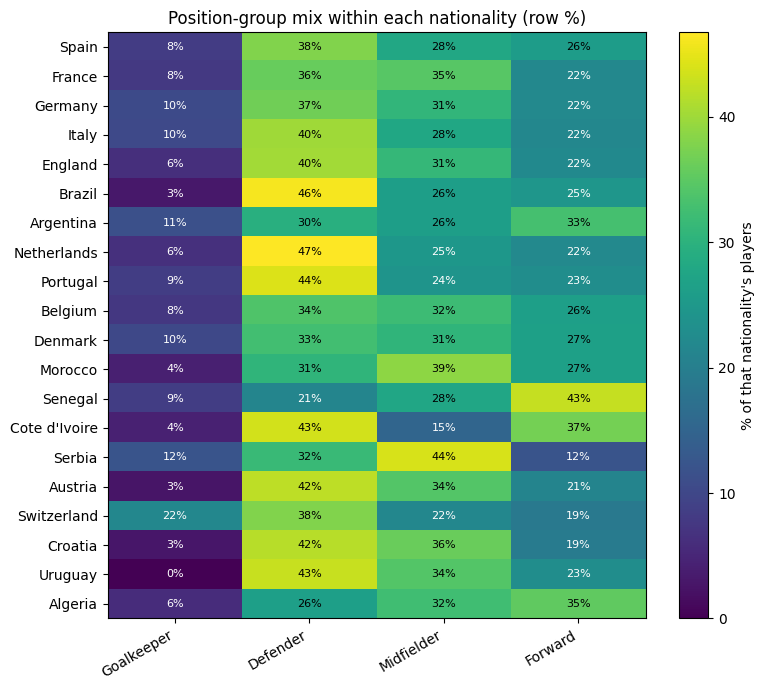

In [38]:
ps_dedup = ps_final.drop_duplicates("player_id")[["player_id", "position_group"]].copy()
ps_dedup["nationality"] = citizenship_lookup.reindex(ps_dedup["player_id"].values).values

nat_pos_counts = pd.crosstab(ps_dedup["nationality"], ps_dedup["position_group"]).reindex(top20_nat.index)
nat_pos_pct = (nat_pos_counts.div(nat_pos_counts.sum(axis=1), axis=0) * 100).reindex(columns=positions_order)

fig, ax = plt.subplots(figsize=(8, 7))
data = nat_pos_pct.values
im = ax.imshow(data, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(nat_pos_pct.columns)))
ax.set_xticklabels(nat_pos_pct.columns, rotation=30, ha="right")
ax.set_yticks(range(len(nat_pos_pct.index)))
ax.set_yticklabels(nat_pos_pct.index)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        color = "white" if data[i, j] < np.nanmean(data) else "black"
        ax.text(j, i, f"{data[i, j]:.0f}%", ha="center", va="center", fontsize=8, color=color)
fig.colorbar(im, ax=ax, label="% of that nationality's players")
ax.set_title("Position-group mix within each nationality (row %)")
plt.tight_layout()
plt.show()


**Finding:** a few nationalities show a real skew rather than roughly matching
the ~25%-per-position baseline:
- **Nigeria (n=34) and Senegal (n=47) are heavily forward-weighted** (56% and
  43% of their players are forwards, vs. ~22-26% for the largest European
  groups) -- consistent with West Africa's well-known reputation as a source
  of attacking talent.
- **Switzerland (n=37) is unusually goalkeeper-heavy** (22% vs. ~8-10%
  typical), and **Serbia/Morocco skew midfielder-heavy** (~39-44%).
- The five largest nationalities (Spain, France, Germany, Italy, England) all
  sit close to a defender-heavy but otherwise fairly even mix, which makes
  sense since they're large enough samples to look more like the overall
  population rather than a specialized pipeline.
As with 11.1, the striking percentages belong to the *smaller* nationality
groups -- exactly where a handful of players can swing a percentage a lot, so
treat these as suggestive patterns worth a footnote, not firm claims.

### 11.3 Average age by nationality

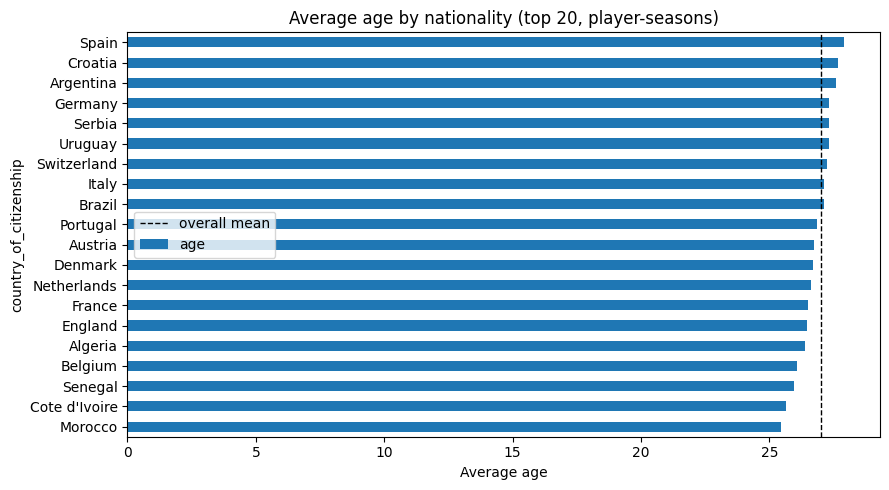

In [39]:
ps_final_nat = ps_final.copy()
ps_final_nat["nationality"] = citizenship_lookup.reindex(ps_final_nat["player_id"].values).values
avg_age_by_nat = (
    ps_final_nat[ps_final_nat["nationality"].isin(top20_nat.index)]
    .groupby("nationality")["age"].mean()
    .reindex(top20_nat.index)
)

fig, ax = plt.subplots(figsize=(9, 5))
avg_age_by_nat.sort_values().plot(kind="barh", ax=ax, title="Average age by nationality (top 20, player-seasons)")
ax.axvline(ps_final["age"].mean(), color="black", linestyle="--", linewidth=1, label="overall mean")
ax.set_xlabel("Average age")
ax.legend()
plt.tight_layout()
plt.show()


Average ages sit in a fairly narrow band (about 25.3 to 27.9) around the
overall mean of 27.0 -- Nigeria and Morocco skew youngest (~25.3-25.4, matching
their forward-heavy, breakout-prospect profile from 11.2), while Spain,
Argentina, and Croatia skew a bit older (~27.6-27.9). Nothing here looks like a
dramatic outlier; age composition by nationality is a much weaker pattern than
the position-mix pattern in 11.2.

### 11.4 Does the value-vs-age curve differ for the largest nationalities?

We compare the two largest nationalities in `ps_final` (Spain and France)
against the overall `val_scope` population. Note the "largest" ranking differs
slightly between `ps_final`'s player-season population (Spain, then France) and
`val_scope`'s raw valuation-row population used in section 9 (which is
dominated by Italy and Spain, since Serie A logs a very large number of
valuation snapshots) -- we use `ps_final`'s ranking here since that's the
population this section is anchored on, but the discrepancy itself is a small,
useful reminder that "largest group" depends on which table you're counting
rows in.

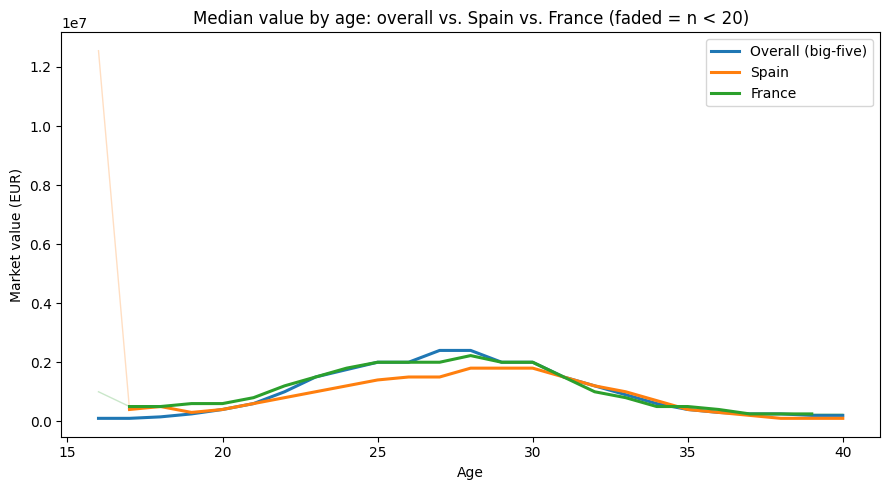

,reliable_peak_age,n_valuation_rows
Overall (big-five),27,191642
Spain,28,27295
France,28,19058


In [40]:
overall_count = val_scope.groupby("age_int").size()
overall_median = val_scope.groupby("age_int")["market_value_in_eur"].median()

fig, ax = plt.subplots(figsize=(9, 5))
curves = pd.DataFrame({"Overall (big-five)": overall_median})
counts = pd.DataFrame({"Overall (big-five)": overall_count})
for nat in ["Spain", "France"]:
    sub = val_scope[val_scope["country_of_citizenship"] == nat]
    curves[nat] = sub.groupby("age_int")["market_value_in_eur"].median()
    counts[nat] = sub.groupby("age_int").size()

plot_age_curves(ax, curves, counts, title="Median value by age: overall vs. Spain vs. France (faded = n < 20)")
plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "reliable_peak_age": reliable_argmax(curves, counts),
    "n_valuation_rows": {c: int(counts[c].sum()) for c in curves.columns},
}))


**Finding:** both Spain and France peak (reliably) at age **28**, one year
later than the overall big-five population's peak of **27**, but otherwise
track the overall curve closely in level and shape -- there's no dramatic
divergence for either of the two largest nationality groups. That's a mildly
reassuring result for M4: the aggregate age-value curve doesn't appear to be an
artifact of one or two dominant nationalities pulling it in a direction that
wouldn't hold for the population as a whole.

### 11.5 A note on citizenship vs. birth country

We used `country_of_citizenship` throughout this section because it's the
football-relevant definition of nationality (it determines national-team
eligibility), but `players` also has `country_of_birth`, and the two disagree
for about 16% of players with both fields populated (6,986 of 43,064) --
players who moved countries young, hold dual nationality, or represent a
country other than the one they were born in. We don't attempt to resolve
which field is "more correct" here; we simply flag that a different, defensible
choice of nationality field would shift some players between groups, mostly at
the margins of the top-20 list above rather than for the largest (Spain,
France, Germany) groups.

## Summary of additional findings

**Market value by age and position (section 9):**
- Reliable (n >= 20) peak market-value age by position, using the median:
  **Forward 25, Midfielder 26, Defender 27, Goalkeeper 27.** The mean and
  log-based geometric-mean summaries shift these estimates by 1-3 years
  (forwards move from 25 to 28 on the log-based measure) -- "peak age" is
  sensitive to which summary statistic is used, not a single fixed number.
- Money variables are strongly right-skewed (raw skewness ~5.4, log10 skewness
  ~0.1): **trust the median for central tendency**, and use log-scale summaries
  whenever distribution shape matters (box/violin plots, future modeling).
- Post-peak decline rate differs a lot by position: **defenders decline
  fastest (-21.9%/yr)**, **goalkeepers decline slowest (-12.9%/yr)** despite a
  much lower peak value -- decline speed does not simply mirror peak age or
  peak value and needs its own per-position estimate in M4.
- The thin-tail risk already flagged in section 8 reappears identically in the
  valuation data (goalkeepers under ~20, all positions past ~35) -- confirming
  it's a real, data-source-independent limitation, not an artifact of the
  performance-data aggregation.

**League-based analysis (section 10):**
- The Premier League has the highest market value on every measure (median
  EUR 3.0M vs. EUR 0.7-1.4M for the other four) and pays a premium across
  every position, largest for forwards. Serie A has the *most* valuation
  records but the *lowest* median value -- sample size and typical value are
  not correlated across leagues.
- A naive age-of-peak search initially said La Liga peaks at age 16 -- a
  single-observation thin-tail artifact. Restricting to reliably-sampled ages
  fixes this: **no league's peak age differs meaningfully from the 26-27 range
  found across positions overall.** This is a concrete demonstration that
  finer-grained slices (by league, or by nationality below) are far more
  exposed to thin-tail artifacts than the position-level aggregates, and any
  future peak-age estimate should apply the same reliability filter.
- The big five leagues are 5 of 31 domestic leagues in the dataset (~16%) but
  ~34% of all domestic-league valuation rows, with double the all-domestic
  median value -- confirms the big-five scope choice targets the right tier,
  purely as context, without expanding this project's actual scope.

**Nationality analysis (section 11):**
- Spain, France, Germany, Italy, and England are the five largest
  nationalities in the M2 analysis-ready population (unsurprising given the
  big-five-league scope); Brazil is the largest non-European group.
- England has the highest current market value by far among top-20
  nationalities (median EUR 6.0M) -- consistent with the Premier League
  premium found in section 10 -- but on a smaller sample (n=189) than Spain or
  France, so this should be read as directional, not precise.
- A few smaller nationality groups show real position concentration (Nigeria
  and Senegal skew heavily toward forwards; Switzerland skews toward
  goalkeepers), while the five largest nationalities all look close to the
  overall population's position mix.
- The two largest nationalities (Spain, France) both peak reliably at age 28,
  one year later than the overall population's 27, but otherwise track the
  overall value-by-age curve closely -- no evidence the aggregate curve is an
  artifact of any single dominant nationality.
- `country_of_citizenship` and `country_of_birth` disagree for ~16% of players
  with both fields populated -- worth a one-line caveat wherever "nationality"
  is used later in the project, but not worth resolving further at this stage.

**Cross-cutting methodological note:** the single most useful pattern across
all three sections is that **naive summary statistics (argmax, raw mean) are
progressively more fragile the finer the slice** -- position-level peak ages
were robust to the thin-tail filter, but league- and nationality-level splits
were not, and would have produced a nonsensical "peaks at 16" finding without
it. M4's curve fitting should apply an explicit reliability threshold (or a
smoothing method that naturally downweights sparse regions, like LOESS) by
default, not just as an afterthought for the age extremes.